#Menghubungkan dengan google collab

In [1]:
from google.colab import drive
drive.mount('/content/drive')
path = "/content/drive/MyDrive/praktikum_ml/praktikum13"

Mounted at /content/drive


###**BussnisUnderstanding**
Tujuan : membantu perusahaan pelayaran atau pihak
terkait memahami faktor faktor yang mempengaruhi keslamatan penumpang serta memprediksi kemungkinan selamatnya penumpang berdasarkan karakteristik tertentu.

Manfaat :
*   Memberikan insight untuk perbaikan sistem keslamatan dimasa depan
*   Dapat digunakan untuk pelatihan model prediksi pada kasus serupa di indrustri transportasi






#Import Library

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split

#Load Data Set

In [3]:
df = pd.read_csv(path + "/data/titanic_data.csv")
df.head()

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


#Pemeriksaan Missing Values

In [4]:
print("\nJumlah Missing Values (Data Kosong) per Kolom:")
df.isnull().sum()


Jumlah Missing Values (Data Kosong) per Kolom:


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


#Data Cleaning

##Menghapus Kolom yang Tidak Digunakan

In [5]:
# Menghapus 'Cabin' (Missing Value besar), 'Name', dan 'Ticket' (teks unik)
df = df.drop(columns=['Cabin', 'Name', 'Ticket'], axis=1)

##Visualisasi Distribusi dan Oulier Kolom age

<Axes: >

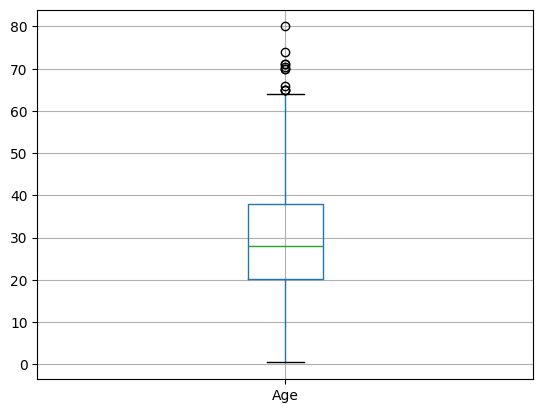

In [6]:
df.boxplot(column=['Age'])

##Mengisi Nilai Kosong pada Kolom Age dengan Median

In [7]:
# Menggunakan median karena kolom Age memiliki outlier
df['Age'].fillna(df['Age'].median(), inplace=True)

/tmp/ipython-input-3289093014.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)


##Mengisi Nilai Kosong pada Kolom Embarked dengan Modus

In [8]:
# Jumlah missing value Embarked sedikit (hanya 2)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

/tmp/ipython-input-699544575.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)


##Verifikasi Ulang Missing Values

In [9]:
print("\nMissing values setelah cleaning:")
df.isnull().sum()


Missing values setelah cleaning:


,0
PassengerId,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


##Encoding Data Kategorikal

In [10]:
# Mengubah nilai teks pada kolom 'Sex' dan 'Embarked' menjadi numerik
replacements = {
    'Sex': {'male': 0, 'female': 1},
    'Embarked': {'S': 0, 'C': 1, 'Q': 2}
}
df.replace(replacements, inplace=True)

/tmp/ipython-input-75819114.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace(replacements, inplace=True)


In [11]:
print("\nDataset setelah Encoding Kategorikal (Head):")
df.head()


Dataset setelah Encoding Kategorikal (Head):


,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,0,22.0,1,0,7.2500,0
1,2,1,1,1,38.0,1,0,71.2833,1
2,3,1,3,1,26.0,0,0,7.9250,0
3,4,1,1,1,35.0,1,0,53.1000,0
4,5,0,3,0,35.0,0,0,8.0500,0


#Split Data dan Transformasi (Scaling)

##Split Data Variabel X dan Y

In [12]:
# X = Fitur Input, y = Target Output ('Survived')
X = df.drop('Survived', axis=1)
y = df['Survived']

##Transformasi Data (Scaling)

In [13]:
# Menggunakan RobustScaler (lebih tahan terhadap outlier dibanding StandardScaler)
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

##Membagi Data Latih dan Data Uji

In [14]:
# Data latih (80%) dan Data uji (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

#Modelling

In [15]:
X_train.shape

(712, 8)

In [16]:
X_train.shape[1]

8

#Pembuatan Model Neural Network (Arsitektur ANN)

In [17]:
# TensorFlow/Keras untuk membangun ANN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

model = Sequential()

# Hidden layer 1
model.add(Dense(32, activation='relu', input_shape=(X_train.shape[1],)))

model.add(Dropout(0.3)) # Dropout 30%

# Hidden layer 2
model.add(Dense(16, activation='relu'))
model.add(Dropout(0.3))

# Output Layer: 1 neuron, Sigmoid (Klasifikasi Biner)
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#Kompilasi Model

In [18]:
model.compile(
    optimizer='adam', # Algoritma optimasi
    loss='binary_crossentropy', # Fungsi kerugian untuk klasifikasi biner
    metrics=['accuracy'] # Metrik evaluasi
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 833 (3.25 KB)

 Trainable params: 833 (3.25 KB)

 Non-trainable params: 0 (0.00 B)

#Early Stopping (Pencegahan Overfitting)

In [19]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(
    monitor='val_loss', # Memantau Validation Loss
    patience=5, # Menunggu 5 epoch tanpa perbaikan
    restore_best_weights=True # Mengembalikan bobot terbaik
)


#Training Model Neural Network

In [20]:
print("\nMemulai Training Model...")
history = model.fit(
    X_train,
    y_train,
    epochs=100, # Max epoch
    batch_size=16, # Ukuran batch
    validation_split=0.2, # 20% data latih menjadi data validasi
    callbacks=[early_stop], # Mengaktifkan Early Stopping
    verbose=1
)


Memulai Training Model...
Epoch 1/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.5287 - loss: 0.7415 - val_accuracy: 0.6154 - val_loss: 0.6863
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6132 - loss: 0.6796 - val_accuracy: 0.6783 - val_loss: 0.6550
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6121 - loss: 0.6652 - val_accuracy: 0.6853 - val_loss: 0.6294
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6483 - loss: 0.6531 - val_accuracy: 0.6993 - val_loss: 0.6030
Epoch 5/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6535 - loss: 0.6426 - val_accuracy: 0.7203 - val_loss: 0.5773
Epoch 6/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7036 - loss: 0.5997 - val_accuracy: 0.7483 - val_loss: 0.5521
Epoch 7/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7197 - loss: 0.5683 - val_accuracy: 0.7622 - val_loss: 0.5321
Epoch 8/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7234 - loss: 0.5654

#Evaluasi Model (Testing Data)

In [21]:
print("\n--- Evaluasi Model pada Data Uji (X_test) ---")
loss, accuracy = model.evaluate(X_test, y_test)

print(f"Test Loss: {loss}")
print(f"Test Accuracy: {accuracy}")


--- Evaluasi Model pada Data Uji (X_test) ---
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8190 - loss: 0.3969 
Test Loss: 0.40896880626678467
Test Accuracy: 0.8100558519363403


#Visualisasi Hasil Pelatihan (Accuracy dan Loss)

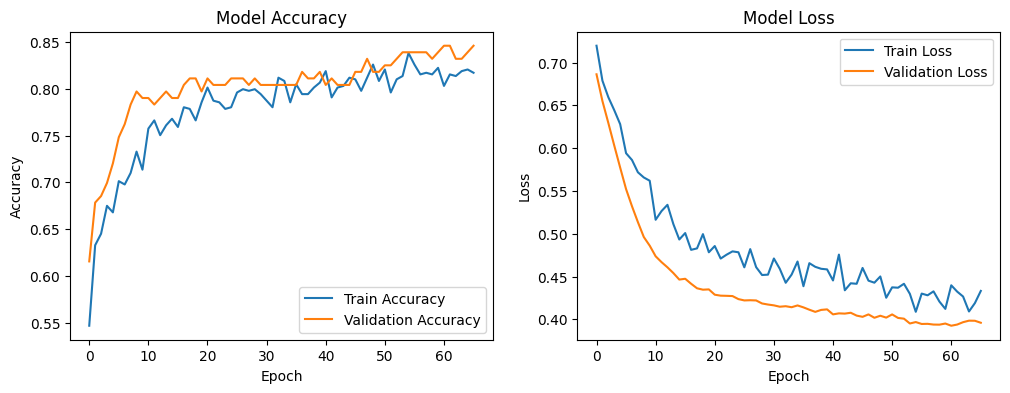

In [22]:
plt.figure(figsize=(12,4))

# Grafik Model Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Grafik Model Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()